In [2]:
!nvidia-smi

Sat May  9 13:01:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   65C    P0             11W /   70W |    1057MiB /   4096MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

In [7]:
!pip install patchify opencv-python

In [10]:
import os
import cv2
import numpy as np
from patchify import patchify

# --- CONFIGURATION ---
original_img_dir = r"D:\Projects\segment\archive\train\sat"
original_mask_dir = r"D:\Projects\segment\archive\train\mask"

save_img_dir = 'dataset/train_images_512/'
save_mask_dir = 'dataset/train_masks_512/'

patch_size = 512
step = 256  

os.makedirs(save_img_dir, exist_ok=True)
os.makedirs(save_mask_dir, exist_ok=True)

# --- PROCESSING ---
file_list = sorted(os.listdir(original_img_dir))

for filename in file_list:
    if filename.endswith("_sat.jpg"):
        
        # 1. Match Filenames
        image_id = filename.replace("_sat.jpg", "")
        mask_filename = image_id + "_mask.png"
        
        img_path = os.path.join(original_img_dir, filename)
        mask_path = os.path.join(original_mask_dir, mask_filename)

        if not os.path.exists(mask_path):
            print(f"Skipping {filename}: Mask not found.")
            continue

        # 2. LOAD BOTH AS COLOR (The '1' flag means Color/RGB)
        image = cv2.imread(img_path, 1)  
        mask = cv2.imread(mask_path, 1) # Changed from 0 to 1

        # 3. PATCHIFY (Both are now 3-Channel Blocks)
        # Shape: (512, 512, 3) for both
        patches_img = patchify(image, (patch_size, patch_size, 3), step=step)
        patches_mask = patchify(mask, (patch_size, patch_size, 3), step=step)

        for i in range(patches_img.shape[0]):
            for j in range(patches_img.shape[1]):
                
                # Extract the single patch (512, 512, 3)
                single_img = patches_img[i, j, 0]
                single_mask = patches_mask[i, j, 0]
                
                save_name = f"{image_id}_{i}_{j}.png"
                
                # Save both as Color PNGs
                cv2.imwrite(os.path.join(save_img_dir, save_name), single_img)
                cv2.imwrite(os.path.join(save_mask_dir, save_name), single_mask)

print("Done! Saved both Images and Masks in full color.")

Done! Saved both Images and Masks in full color.


In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
mask_dir = 'dataset/train_masks_512/' 

background_count = 0
object_count = 0
useful_patches = 0
total_patches = 0

print("Analyzing dataset balance... this may take a moment.")

for filename in os.listdir(mask_dir):
    if filename.endswith(".png"):
        total_patches += 1
        
        # Load mask (force grayscale)
        mask = cv2.imread(os.path.join(mask_dir, filename), 0)
        
        # Check if the mask is 0-255 or 0-1. 
        # If max value is > 1, we assume objects are 255 (white).
        if np.max(mask) > 1:
            mask = mask / 255.0
            
        # Count pixels
        # Assuming 0 = Background, 1 = Object
        # 'sum' adds up all the 1s (object pixels)
        obj_pixels = np.sum(mask == 1)
        bg_pixels = np.sum(mask == 0)
        
        object_count += obj_pixels
        background_count += bg_pixels
        
        # Check if this patch actually contains any objects
        if obj_pixels > 0:
            useful_patches += 1

# --- RESULTS ---
total_pixels = background_count + object_count
obj_ratio = (object_count / total_pixels) * 100
bg_ratio = (background_count / total_pixels) * 100

print("-" * 30)
print(f"Total Patches Scanned: {total_patches}")
print(f"Patches with Objects:  {useful_patches} ({(useful_patches/total_patches)*100:.1f}%)")
print("-" * 30)
print(f"Background Pixels:     {bg_ratio:.2f}%")
print(f"Object Pixels:         {obj_ratio:.2f}%")
print("-" * 30)

# Verdict
if obj_ratio < 5:
    print("⚠️ SEVERE IMBALANCE DETECTED!")
    print("Recommendation: Use 'Focal Loss' or 'Dice Loss' instead of standard CrossEntropy.")
elif obj_ratio < 15:
    print("⚠️ Moderate Imbalance.")
    print("Recommendation: Use Class Weights (e.g., weight=10 for objects).")
else:
    print("✅ Dataset is well-balanced.")

Analyzing dataset balance... this may take a moment.


TypeError: '>' not supported between instances of 'NoneType' and 'int'

In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

class SatelliteDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir)) # Ensure they align!
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # 1. Read Image (RGB) and Normalize to 0-1
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # OpenCV loads as BGR
        image = image / 255.0  
        image = image.astype('float32')
        
        # 2. Read Mask (Grayscale) and Normalize to 0-1
        mask = cv2.imread(mask_path, 0)
        mask = mask / 255.0  
        mask = mask.astype('float32')

        # 3. Transpose dimensions for PyTorch
        # PyTorch wants (Channels, Height, Width)
        # Images currently: (512, 512, 3) -> Need (3, 512, 512)
        image = image.transpose(2, 0, 1)
        
        # Masks currently: (512, 512) -> Need (1, 512, 512)
        mask = np.expand_dims(mask, axis=0)

        return torch.from_numpy(image), torch.from_numpy(mask)

In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2, feature, kernel_size=2, stride=2
                )
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder (Down)
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        
        # Reverse list of skip connections
        skip_connections = skip_connections[::-1]

        # Decoder (Up)
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x) # Upsample
            skip_connection = skip_connections[idx//2]

            # If input shape is not perfectly divisible by 2, resize might be needed here.
            # But with 512x512, it divides perfectly, so we can concatenate directly.
            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1) # Concatenate along channel axis
            x = self.ups[idx+1](concat_skip) # Double Conv

        return self.final_conv(x)

# --- QUICK TEST ---
# Run this to make sure it fits in your GPU memory before training
if __name__ == "__main__":
    # Create model
    model = UNet(in_channels=3, out_channels=1).cuda()
    
    # Create a dummy image (Batch Size 2, RGB, 512x512)
    x = torch.randn((2, 3, 512, 512)).cuda()
    
    # Forward pass
    preds = model(x)
    
    print(f"Input Shape: {x.shape}")
    print(f"Output Shape: {preds.shape}") # Should be [2, 1, 512, 512]
    print("Success! The custom U-Net is ready.")

Input Shape: torch.Size([2, 3, 512, 512])
Output Shape: torch.Size([2, 1, 512, 512])
Success! The custom U-Net is ready.


In [ ]:
import torch

# This automatically picks the GPU if available, otherwise falls back to CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")
# On your machine, this should print: "Using device: cuda"

Using device: cuda


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(Convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- DROPOUT ADDED HERE ---
        # 0.5 = 50% probability of dropping a neuron
        self.dropout = nn.Dropout(p=0.5)

        # Down part of UNet
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2, feature, kernel_size=2, stride=2
                )
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder (Down)
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        
        # --- DROPOUT APPLIED HERE ---
        x = self.dropout(x)

        # Reverse list of skip connections
        skip_connections = skip_connections[::-1]

        # Decoder (Up)
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x) # Upsample
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1) 
            x = self.ups[idx+1](concat_skip) 

        return self.final_conv(x)

# --- QUICK TEST ---
if __name__ == "__main__":
    # Check for CUDA
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Testing model on: {device}")
    
    # Create model
    model = UNet(in_channels=3, out_channels=1).to(device)
    
    # Create a dummy image (Batch Size 2, RGB, 512x512)
    # This matches your RTX 2050 settings
    x = torch.randn((2, 3, 512, 512)).to(device)
    
    # Forward pass
    preds = model(x)
    
    print(f"Input Shape: {x.shape}")
    print(f"Output Shape: {preds.shape}") # Should be [2, 1, 512, 512]
    print("Success! Custom U-Net with Dropout is ready.")

Testing model on: cuda
Input Shape: torch.Size([2, 3, 512, 512])
Output Shape: torch.Size([2, 1, 512, 512])
Success! Custom U-Net with Dropout is ready.


In [ ]:
!pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


🎲 Randomly selected ID: 2774
   Found 64 patches.
   Reconstructed Size: 2304 x 2304


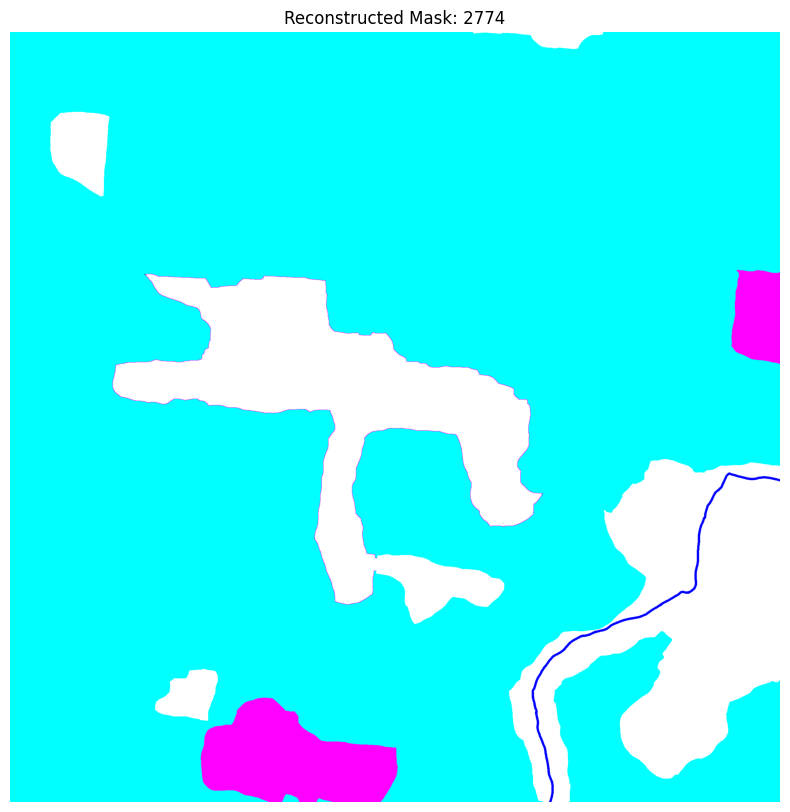

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# --- CONFIGURATION ---
MASK_PATCH_DIR = 'dataset/train_masks_512/' 
PATCH_SIZE = 512
STEP = 256  # Must match your patchify step!

# --- 1. FIND ALL UNIQUE IDs ---
all_files = os.listdir(MASK_PATCH_DIR)
unique_ids = set()

for f in all_files:
    if f.endswith(".png"):
        # Filename format: "ID_Row_Col.png" -> e.g., "119_0_1.png" or "43872_1_6_4.png"
        # We need to strip off the last two parts (_Row_Col) to get the ID
        
        name_no_ext = os.path.splitext(f)[0]
        parts = name_no_ext.split('_')
        
        # The ID is everything BEFORE the last two parts
        # e.g. parts = ['119', '0', '1'] -> ID = "119"
        # e.g. parts = ['43872', '1', '6', '4'] -> ID = "43872_1"
        
        if len(parts) >= 3:
            img_id = "_".join(parts[:-2])
            unique_ids.add(img_id)

if not unique_ids:
    print("❌ No valid patches found in folder.")
else:
    # --- 2. PICK RANDOM ID ---
    TEST_ID = random.choice(list(unique_ids))
    print(f"🎲 Randomly selected ID: {TEST_ID}")
    
    # Filter files for this specific ID
    patch_files = [f for f in all_files if f.startswith(TEST_ID + "_")]
    print(f"   Found {len(patch_files)} patches.")

    # --- 3. CALCULATE CANVAS SIZE ---
    max_row = 0
    max_col = 0

    for f in patch_files:
        name_no_ext = os.path.splitext(f)[0]
        parts = name_no_ext.split('_')
        
        # Last two are Row and Col
        row = int(parts[-2])
        col = int(parts[-1])
        
        if row > max_row: max_row = row
        if col > max_col: max_col = col

    full_height = (max_row * STEP) + PATCH_SIZE
    full_width = (max_col * STEP) + PATCH_SIZE
    
    print(f"   Reconstructed Size: {full_width} x {full_height}")

    # --- 4. CREATE CANVAS ---
    # Check if Color or Gray
    first_patch = cv2.imread(os.path.join(MASK_PATCH_DIR, patch_files[0]), -1)
    
    if len(first_patch.shape) == 3:
        canvas = np.zeros((full_height, full_width, 3), dtype=np.uint8)
        is_color = True
    else:
        canvas = np.zeros((full_height, full_width), dtype=np.uint8)
        is_color = False

    # --- 5. STITCH ---
    for f in patch_files:
        path = os.path.join(MASK_PATCH_DIR, f)
        patch = cv2.imread(path, -1)
        
        if patch is None: continue

        name_no_ext = os.path.splitext(f)[0]
        parts = name_no_ext.split('_')
        row = int(parts[-2])
        col = int(parts[-1])

        y = row * STEP
        x = col * STEP

        if is_color:
            canvas[y:y+PATCH_SIZE, x:x+PATCH_SIZE, :] = patch
        else:
            canvas[y:y+PATCH_SIZE, x:x+PATCH_SIZE] = patch

    # --- 6. DISPLAY ---
    plt.figure(figsize=(10, 10))
    if is_color:
        plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(canvas, cmap='gray')
        
    plt.title(f"Reconstructed Mask: {TEST_ID}")
    plt.axis("off")
    plt.show()

✅ Loaded Class Dictionary.
🔍 Fetching a random training batch...


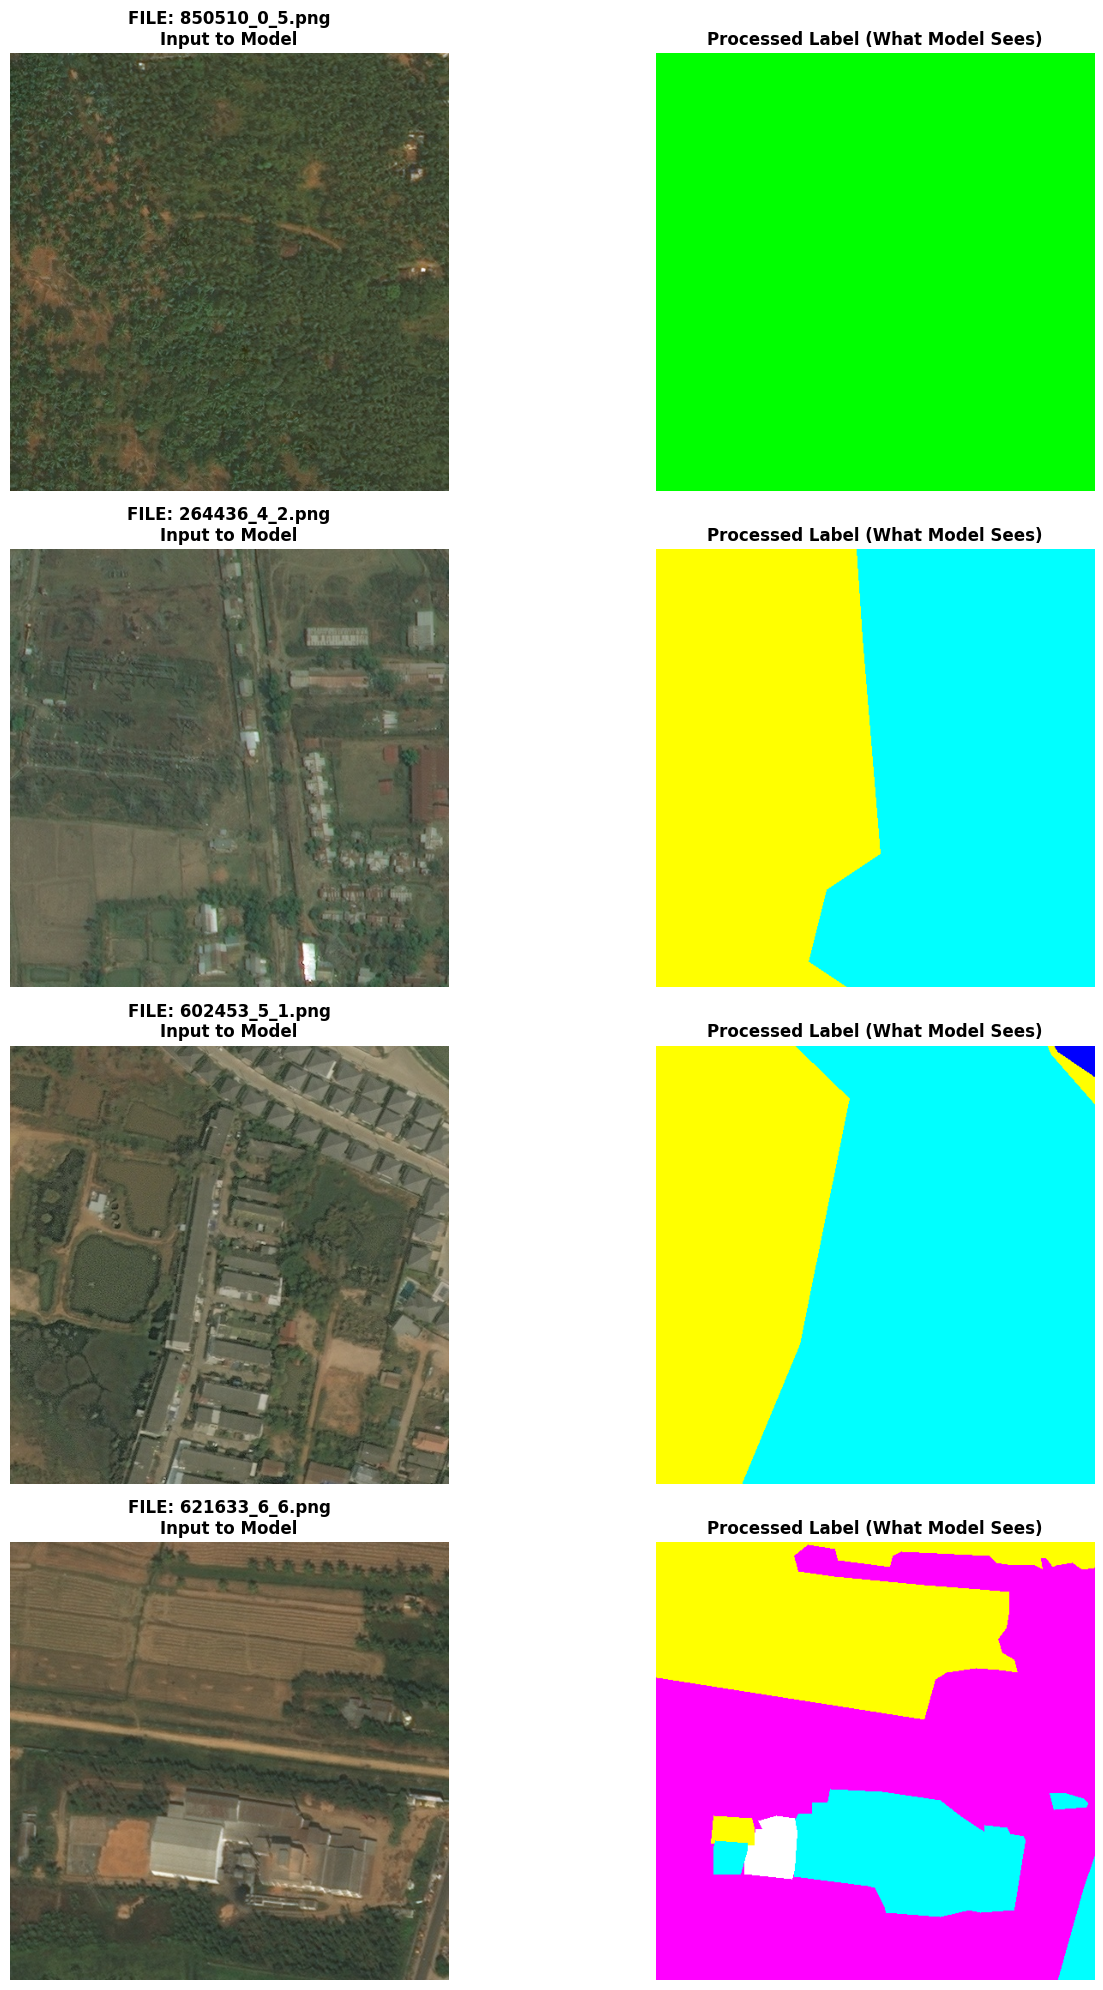

In [13]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
IMG_DIR = 'dataset/train_images_512/'
MASK_DIR = 'dataset/train_masks_512/'
CLASS_DICT_PATH = 'class_dict.csv'
BATCH_SIZE = 4

# --- 1. LOAD CLASS DICTIONARY ---
try:
    class_df = pd.read_csv(CLASS_DICT_PATH)
    class_rgb_values = class_df[['r', 'g', 'b']].values.tolist()
    print("✅ Loaded Class Dictionary.")
except:
    print("❌ Error: Could not find class_dict.csv")
    exit()

# --- 2. DEFINE VERIFICATION DATASET ---
# This is identical to your training dataset, BUT it returns the FILENAME too.
class VerificationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, rgb_values):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.rgb_values = rgb_values
        self.images = [f for f in os.listdir(image_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # 1. Load Image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 2. Load Mask
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        # 3. Preprocess Image (Normalize)
        image = image / 255.0
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)

        # 4. Preprocess Mask (Color -> Index)
        # We REPLICATE the exact training logic here to catch errors
        mask_class_map = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
        for i, rgb in enumerate(self.rgb_values):
            match = np.all(np.abs(mask - np.array(rgb)) < 10, axis=-1)
            mask_class_map[match] = i

        return torch.from_numpy(image), torch.from_numpy(mask_class_map), img_name

# --- 3. HELPER: CONVERT INDEX BACK TO COLOR ---
def map_index_to_rgb(mask_idx, colors):
    # mask_idx: (H, W) with values 0..N
    h, w = mask_idx.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for i, color in enumerate(colors):
        rgb_mask[mask_idx == i] = color
    return rgb_mask

# --- 4. RUN VERIFICATION LOOP ---
# Create Dataset & Loader
ds = VerificationDataset(IMG_DIR, MASK_DIR, class_rgb_values)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)

# Fetch one batch
print("🔍 Fetching a random training batch...")
images, masks, filenames = next(iter(loader))

# Plot the batch
plt.figure(figsize=(15, 5 * BATCH_SIZE))

for i in range(len(images)):
    img_tensor = images[i]
    mask_tensor = masks[i]
    fname = filenames[i]

    # --- Convert Image Tensor back to Numpy ---
    # (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    
    # --- Convert Mask Tensor back to RGB ---
    mask_np = mask_tensor.numpy()
    mask_colored = map_index_to_rgb(mask_np, class_rgb_values)

    # Plot
    plt.subplot(BATCH_SIZE, 2, 2*i + 1)
    plt.imshow(img_np)
    plt.title(f"FILE: {fname}\nInput to Model", fontweight='bold')
    plt.axis('off')

    plt.subplot(BATCH_SIZE, 2, 2*i + 2)
    plt.imshow(mask_colored)
    plt.title(f"Processed Label (What Model Sees)", fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install pandas


^C


In [ ]:

import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# --- CONFIGURATION ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 1e-4
BATCH_SIZE = 4        # Lower to 2 if you get OOM
EPOCHS = 15           # Multi-class usually needs more epochs
IMG_DIR = 'dataset/train_images_512/'
MASK_DIR = 'dataset/train_masks_512/'
CLASS_DICT_PATH = 'class_dict.csv'  # Make sure this file is in your folder!

# --- 1. READ CLASS DICTIONARY ---
# We need to know: (R,G,B) -> Class ID (0, 1, 2...)
class_df = pd.read_csv(CLASS_DICT_PATH)
class_names = class_df['name'].tolist()
class_rgb_values = class_df[['r', 'g', 'b']].values.tolist()

print(f"✅ Found {len(class_names)} Classes in CSV:")
for i, (name, rgb) in enumerate(zip(class_names, class_rgb_values)):
    print(f"   Class {i}: {name} -> RGB{rgb}")

# --- 2. DATASET CLASS (RGB -> Class ID) ---
class SatelliteDataset(Dataset):
    def __init__(self, image_dir, mask_dir, rgb_values):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.rgb_values = rgb_values
        
        # Load all patch files
        self.images = [f for f in os.listdir(image_dir) if f.endswith('.png')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # 1. Load Image (RGB)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 2. Load Mask (RGB)
        # Note: We read as Color because the colors represent classes
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        # 3. Preprocess Image (Normalize)
        image = image / 255.0
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)

        # 4. Preprocess Mask (Color -> Index)
        # We need to convert the (512, 512, 3) RGB mask into a (512, 512) Index mask
        # where each pixel is 0, 1, 2, etc.
        
        mask_class_map = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
        
        # Loop through known classes and map pixels
        for i, rgb in enumerate(self.rgb_values):
            # Find all pixels that match this class color
            # Using a tolerance of 10 for compression artifacts
            match = np.all(np.abs(mask - np.array(rgb)) < 10, axis=-1)
            mask_class_map[match] = i

        return torch.from_numpy(image), torch.from_numpy(mask_class_map)

# --- 3. MODEL (U-Net for Multi-Class) ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes, in_channels=3, features=[32, 64, 128, 256]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up
        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        
        # FINAL LAYER: Outputs 'n_classes' channels instead of 1
        self.final_conv = nn.Conv2d(features[0], n_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

# --- 4. TRAINING LOOP ---
def train_fn(loader, model, optimizer, loss_fn, scaler):
    loop = tqdm(loader)
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(DEVICE)
        targets = targets.to(DEVICE) # Shape: [Batch, 512, 512] (Values 0..N)

        with torch.cuda.amp.autocast():
            predictions = model(data) # Shape: [Batch, N_Classes, 512, 512]
            loss = loss_fn(predictions, targets)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loop.set_postfix(loss=loss.item())

if __name__ == "__main__":
    # Initialize Dataset
    train_ds = SatelliteDataset(IMG_DIR, MASK_DIR, class_rgb_values)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize Model with Num_Classes from CSV
    NUM_CLASSES = len(class_names)
    print(f"🏗️ Building U-Net for {NUM_CLASSES} classes...")
    
    model = UNet(n_classes=NUM_CLASSES).to(DEVICE)
    
    # CrossEntropyLoss is mandatory for Multi-Class
    loss_fn = nn.CrossEntropyLoss() 
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scaler = torch.cuda.amp.GradScaler()

    print("🚀 Starting Training...")
    for epoch in range(EPOCHS):
        print(f"Epoch {epoch+1}/{EPOCHS}")
        train_fn(train_loader, model, optimizer, loss_fn, scaler)
        
        torch.save(model.state_dict(), "m ulticlass_unet.pth")
        print("Model Saved!")



  
 

✅ Found 7 Classes in CSV:
   Class 0: urban_land -> RGB[0, 255, 255]
   Class 1: agriculture_land -> RGB[255, 255, 0]
   Class 2: rangeland -> RGB[255, 0, 255]
   Class 3: forest_land -> RGB[0, 255, 0]
   Class 4: water -> RGB[0, 0, 255]
   Class 5: barren_land -> RGB[255, 255, 255]
   Class 6: unknown -> RGB[0, 0, 0]
🏗️ Building U-Net for 7 classes...


C:\Users\Khushan\AppData\Local\Temp\ipykernel_11324\3455607212.py:168: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🚀 Starting Training...
Epoch 1/15


  0%|          | 0/10859 [00:00<?, ?it/s]C:\Users\Khushan\AppData\Local\Temp\ipykernel_11324\3455607212.py:143: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
 71%|███████   | 7691/10859 [9:41:22<2:16:16,  2.58s/it, loss=1.19]      

Loading weights from multiclass_unet.pth...
✅ Model loaded! Ready to predict.


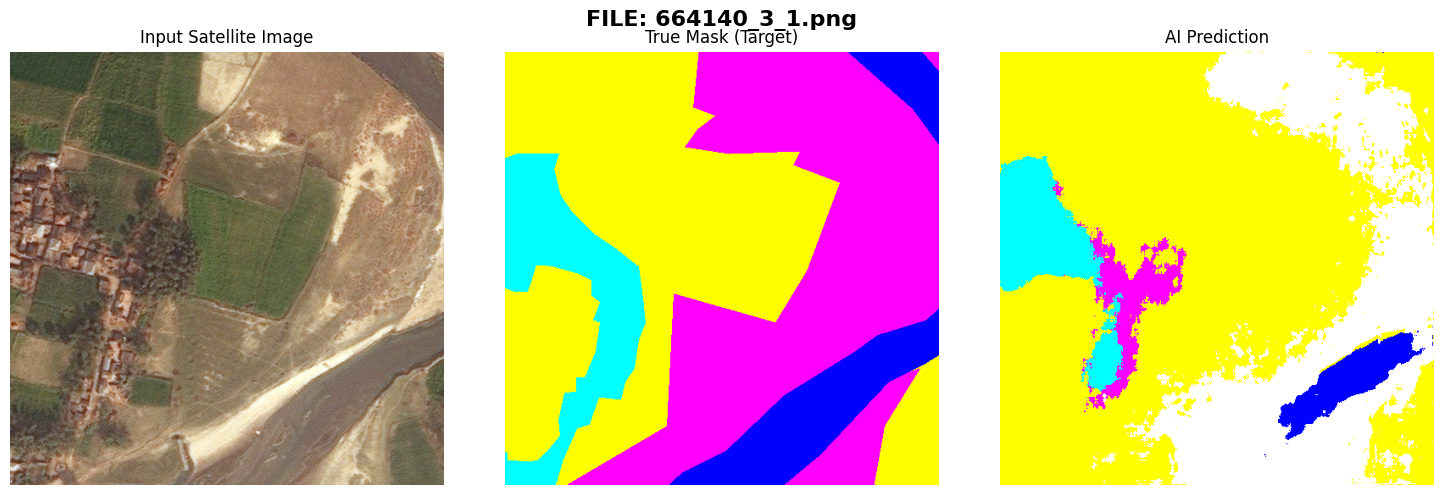

In [22]:
import torch
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np
import os
import random

# --- CONFIGURATION ---
# (Make sure these match your training config!)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "multiclass_unet.pth"
IMG_DIR = 'dataset/train_images_512/'
MASK_DIR = 'dataset/train_masks_512/'
CLASS_DICT_PATH = 'class_dict.csv'

# --- 1. SETUP COLORS ---
class_df = pd.read_csv(CLASS_DICT_PATH)
class_rgb_values = class_df[['r', 'g', 'b']].values.tolist()
n_classes = len(class_rgb_values)

# --- 2. DEFINE MODEL ARCHITECTURE ---
class DoubleConv(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(out_channels),
            torch.nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.double_conv(x)

class UNet(torch.nn.Module):
    def __init__(self, n_classes, in_channels=3, features=[32, 64, 128, 256]):
        super().__init__()
        self.ups = torch.nn.ModuleList()
        self.downs = torch.nn.ModuleList()
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
        for feature in reversed(features):
            self.ups.append(torch.nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = torch.nn.Conv2d(features[0], n_classes, kernel_size=1)
    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)
        return self.final_conv(x)

# --- 3. LOAD THE TRAINED WEIGHTS ---
model = UNet(n_classes=n_classes).to(DEVICE)

if os.path.exists(MODEL_PATH):
    print(f"Loading weights from {MODEL_PATH}...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
    print("✅ Model loaded! Ready to predict.")
else:
    print("⏳ Waiting for training to finish...")

# --- 4. PREDICTION FUNCTION ---
def predict_random_image():
    if not os.path.exists(MODEL_PATH): return

    # Pick random file
    files = [f for f in os.listdir(IMG_DIR) if f.endswith('.png')]
    if not files: return
    img_name = random.choice(files)
    
    # Load Image
    img_path = os.path.join(IMG_DIR, img_name)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Preprocess
    input_tensor = image / 255.0
    input_tensor = np.transpose(input_tensor, (2, 0, 1)).astype(np.float32)
    input_tensor = torch.from_numpy(input_tensor).unsqueeze(0).to(DEVICE)
    
    # Predict
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    
    # Colorize Prediction
    h, w = pred_idx.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for i, color in enumerate(class_rgb_values):
        rgb_mask[pred_idx == i] = color
        
    # Load Ground Truth
    mask_path = os.path.join(MASK_DIR, img_name)
    gt_mask = cv2.imread(mask_path)
    gt_mask = cv2.cvtColor(gt_mask, cv2.COLOR_BGR2RGB)
    
    # Display
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # --- NEW: SHOW FILENAME AT THE TOP ---
    fig.suptitle(f"FILE: {img_name}", fontsize=16, fontweight='bold')
    
    ax[0].imshow(image)
    ax[0].set_title("Input Satellite Image")
    ax[0].axis('off')
    
    ax[1].imshow(gt_mask)
    ax[1].set_title("True Mask (Target)")
    ax[1].axis('off')
    
    ax[2].imshow(rgb_mask)
    ax[2].set_title("AI Prediction")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the prediction check
predict_random_image()

In [ ]:
import cv2
import numpy as np
import os

# POINT THIS TO YOUR MASK FOLDER
MASK_DIR = r"C:\Users\Khushan\Desktop\segment\dataset\train_masks_512"

# Get the first image found
files = [f for f in os.listdir(MASK_DIR) if f.endswith('.png')]
if files:
    img_name = files[0]
    path = os.path.join(MASK_DIR, img_name)
    
    # Read as Grayscale (Index)
    gray = cv2.imread(path, 0)
    print(f"--- Checking {img_name} ---")
    print(f"Unique values found (Grayscale): {np.unique(gray)}")
    
    # Read as Color (RGB)
    color = cv2.imread(path)
    color = cv2.cvtColor(color, cv2.COLOR_BGR2RGB)
    
    # Find unique colors
    # Reshape to list of pixels
    pixels = color.reshape(-1, 3)
    unique_colors = np.unique(pixels, axis=0)
    
    print(f"Unique Colors found (RGB):")
    for c in unique_colors:
        print(f"  {c}")
else:
    print("No images found.")

--- Checking 100694_0_0.png ---
Unique values found (Grayscale): [  0 225]
Unique Colors found (RGB):
  [0 0 0]
  [255 255   0]


In [ ]:
import os
import cv2
import json
import numpy as np
import random
from tqdm import tqdm

# --- CONFIGURATION ---
MASK_DIR = r"C:\Users\Khushan\Desktop\segment\dataset\train_masks_512"
OUTPUT_FILE = "vqa_dataset.json"

# 1. Define your RGB Colors here (Format: [R, G, B])
# Based on your output, Yellow is likely Agriculture.
# UPDATE these if you have other colors!
RGB_MAP = {
    (0, 0, 0): 6,       # Black -> Unknown/Background
    (255, 255, 0): 1,   # Yellow -> Agriculture
    (255, 0, 255): 0,   # Example: Purple -> Urban (Check your dataset!)
    (0, 255, 0): 3,     # Example: Green -> Forest
    (0, 0, 255): 4,     # Example: Blue -> Water
    (255, 255, 255): 5  # Example: White -> Barren
}

CLASSES = {
    0: "Urban Land",
    1: "Agriculture Land",
    2: "Rangeland",
    3: "Forest Land",
    4: "Water",
    5: "Barren Land",
    6: "Unknown"
}

TEMPLATES = {
    "existence": [
        "Is there any {name} in this image?",
        "Can you see {name}?",
        "Does this area contain {name}?",
        "Is {name} present?",
        "Are there traces of {name} here?"
    ],
    "dominance": [
        "What is the primary land use here?",
        "Which feature covers the most area?",
        "What is the dominant landscape?",
        "Most of the image consists of what?"
    ]
}

def rgb_to_id_mask(rgb_img):
    """Converts an RGB mask to a 2D ID mask (0, 1, 2...)"""
    # Create an empty 2D mask
    h, w, _ = rgb_img.shape
    id_mask = np.zeros((h, w), dtype=np.uint8)
    
    # For each defined color, replace pixels with Class ID
    for rgb, class_id in RGB_MAP.items():
        # Find pixels matching this color
        # Note: OpenCV loads as BGR, so we flip RGB to BGR for matching
        bgr = rgb[::-1] 
        mask = np.all(rgb_img == bgr, axis=-1)
        id_mask[mask] = class_id
        
    return id_mask

def generate_data():
    dataset = []
    
    if not os.path.exists(MASK_DIR):
        print(f"Error: Directory '{MASK_DIR}' not found.")
        return

    files = [f for f in os.listdir(MASK_DIR) if f.endswith(('.png', '.jpg'))]
    
    if not files:
        print("No image files found!")
        return

    print(f"Found {len(files)} masks. Converting colors and generating questions...")

    for filename in tqdm(files, unit="img"):
        mask_path = os.path.join(MASK_DIR, filename)
        
        # 1. Read as Color
        color_mask = cv2.imread(mask_path)
        if color_mask is None: continue

        # 2. Convert RGB Colors -> Class IDs (0, 1, 2...)
        mask = rgb_to_id_mask(color_mask)

        # 3. Calculate Stats
        unique, counts = np.unique(mask, return_counts=True)
        pixel_stats = dict(zip(unique, counts))
        total_pixels = mask.size

        # --- GENERATE QUESTIONS ---
        for class_id, class_name in CLASSES.items():
            if class_name == "Unknown": continue

            # If class covers > 1% of pixels, Answer = Yes
            exists = (pixel_stats.get(class_id, 0) / total_pixels) > 0.01
            answer = "Yes" if exists else "No"
            
            # Only add "Yes" questions more frequently to balance data? 
            # For now we add all to be safe.
            q_text = random.choice(TEMPLATES["existence"]).format(name=class_name)
            
            dataset.append({
                "image": filename,
                "question": q_text,
                "answer": answer
            })

        # Dominance
        if pixel_stats:
            dom_id = max(pixel_stats, key=pixel_stats.get)
            dom_name = CLASSES.get(dom_id, "Unknown")
            
            # Skip if dominant is unknown (usually background)
            if dom_name != "Unknown":
                q_text = random.choice(TEMPLATES["dominance"])
                dataset.append({
                    "image": filename,
                    "question": q_text,
                    "answer": dom_name
                })

    with open(OUTPUT_FILE, "w") as f:
        json.dump(dataset, f, indent=4)

    print(f"\nSUCCESS: Generated {len(dataset)} pairs. Saved to {OUTPUT_FILE}")

if __name__ == "__main__":
    generate_data()

Found 45077 masks. Converting colors and generating questions...


100%|██████████| 45077/45077 [20:32<00:00, 36.56img/s] 



SUCCESS: Generated 305157 pairs. Saved to vqa_dataset.json


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import json
import os
import numpy as np
from tqdm import tqdm

# --- USER CONFIGURATION ---
# IMPORTANT: Point this to your ORIGINAL SATELLITE IMAGES
IMAGE_DIR = r"C:\Users\Khushan\Desktop\segment\dataset\train_images_512" 
JSON_FILE = "vqa_dataset.json"
CHECKPOINT_PATH = "multiclass_unet.pth" # Ensure this matches your saved model filename
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 1e-4
# --------------------------

# --- 1. DEFINE U-NET ARCHITECTURE (Must match your saved model!) ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes, in_channels=3, features=[32, 64, 128, 256]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], n_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        
        # --- CAPTURE FEATURES FOR VQA ---
        bottleneck_features = x 
        # --------------------------------

        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = torch.nn.functional.interpolate(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x), bottleneck_features

# --- 2. VQA MODEL WRAPPER ---
class SatelliteVQA(nn.Module):
    def __init__(self, unet_checkpoint, vocab_size, num_classes=7):
        super(SatelliteVQA, self).__init__()
        
        # Initialize U-Net
        self.unet = UNet(n_classes=num_classes)
        
        # Load Weights safely
        if os.path.exists(unet_checkpoint):
            print(f"Loading backbone from {unet_checkpoint}...")
            checkpoint = torch.load(unet_checkpoint, map_location="cpu")
            # If state_dict is inside a key (common in some saves), extract it
            if "state_dict" in checkpoint:
                self.unet.load_state_dict(checkpoint["state_dict"])
            else:
                self.unet.load_state_dict(checkpoint)
        else:
            print(f"⚠️ WARNING: Checkpoint {unet_checkpoint} not found. Using random weights.")

        # FREEZE U-Net Vision Part
        for param in self.unet.parameters():
            param.requires_grad = False
            
        # Question Encoder
        self.q_emb = nn.Embedding(vocab_size, 64)
        self.q_rnn = nn.LSTM(64, 128, batch_first=True)
        
        # Fusion Head 
        # Input = 512 (Bottleneck features) + 128 (Question features)
        self.fusion = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 20) 
        )

    def forward(self, images, question_indices):
        # Vision Branch
        _, features = self.unet(images) 
        
        # Global Average Pooling [Batch, 512, H, W] -> [Batch, 512]
        features = torch.mean(features, dim=[2, 3]) 
        
        # Language Branch
        emb = self.q_emb(question_indices)
        _, (h_n, _) = self.q_rnn(emb)
        q_feat = h_n[-1] 
        
        # Fusion
        combined = torch.cat((features, q_feat), dim=1)
        output = self.fusion(combined)
        return output

# --- 3. DATASET CLASS ---
class VQADataset(Dataset):
    def __init__(self, json_file, img_dir):
        with open(json_file, "r") as f:
            self.data = json.load(f)
        self.img_dir = img_dir
        
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((256, 256)), 
            transforms.ToTensor(),
        ])
        
        self.build_vocab()

    def build_vocab(self):
        words = set()
        answers = set()
        for item in self.data:
            for w in item['question'].lower().replace("?", "").split():
                words.add(w)
            answers.add(item['answer'])
            
        self.vocab = {w: i+1 for i, w in enumerate(words)}
        self.answer_map = {a: i for i, a in enumerate(answers)}
        self.idx_to_answer = {i: a for a, i in self.answer_map.items()}
        print(f"Vocab Size: {len(self.vocab)} | Answers: {len(self.answer_map)}")

    def text_to_indices(self, text):
        indices = [self.vocab.get(w, 0) for w in text.lower().replace("?", "").split()]
        max_len = 10
        if len(indices) < max_len:
            indices += [0] * (max_len - len(indices))
        else:
            indices = indices[:max_len]
        return indices

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.img_dir, item['image'])
        
        # Handle extension mismatch (e.g., png vs jpg)
        if not os.path.exists(img_path):
            base = os.path.splitext(img_path)[0]
            if os.path.exists(base + ".jpg"): img_path = base + ".jpg"
            elif os.path.exists(base + ".png"): img_path = base + ".png"
        
        image = cv2.imread(img_path)
        if image is None: # Fallback black image
            image = np.zeros((256, 256, 3), dtype=np.uint8)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = self.transform(image)
        
        q_indices = torch.tensor(self.text_to_indices(item['question']), dtype=torch.long)
        a_index = torch.tensor(self.answer_map[item['answer']], dtype=torch.long)
        
        return image, q_indices, a_index

# --- 4. MAIN TRAINING LOOP ---
def train():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Starting VQA Training on {device}...")
    
    if not os.path.exists(IMAGE_DIR):
        print(f"ERROR: Image directory {IMAGE_DIR} not found.")
        return

    # Load Data
    dataset = VQADataset(JSON_FILE, IMAGE_DIR)
    vocab_size = len(dataset.vocab) + 1 
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Load Model
    # Note: We pass vocab_size here!
    model = SatelliteVQA(CHECKPOINT_PATH, vocab_size).to(device)
    
    # Optimizer
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    
    # Train
    for epoch in range(EPOCHS):
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
        total_loss = 0
        
        for images, questions, answers in loop:
            images, questions, answers = images.to(device), questions.to(device), answers.to(device)
            
            outputs = model(images, questions)
            loss = criterion(outputs, answers)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
            
    # Save
    torch.save(model.state_dict(), "vqa_model_final.pth")
    
    # Save Answers for Inference
    with open("vqa_answers.json", "w") as f:
        json.dump(dataset.idx_to_answer, f)
        
    print("\nTraining Complete! Model saved as 'vqa_model_final.pth'")

if __name__ == "__main__":
    train()

Starting VQA Training on cuda...
Vocab Size: 35 | Answers: 7
Loading backbone from multiclass_unet.pth...


Epoch 5/5: 100%|██████████| 38145/38145 [2:06:40<00:00,  5.02it/s, loss=0.431]    



Training Complete! Model saved as 'vqa_model_final.pth'


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import cv2
import json
import os
import random
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURATION ---
IMAGE_DIR = r"C:\Users\Khushan\Desktop\segment\dataset\train_images_512" 
MODEL_PATH = "vqa_model_final.pth"
ANSWERS_FILE = "vqa_answers.json"
VOCAB_FILE = "vqa_vocab.json" # If you saved this during training, otherwise we rebuild it

# ---------------------

# 1. DEFINE THE ARCHITECTURE (Must match training!)
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_classes, in_channels=3, features=[32, 64, 128, 256]):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], n_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        bottleneck_features = x 
        return None, bottleneck_features # We only need features for VQA

class SatelliteVQA(nn.Module):
    def __init__(self, vocab_size, num_classes=7):
        super(SatelliteVQA, self).__init__()
        self.unet = UNet(n_classes=num_classes)
        self.q_emb = nn.Embedding(vocab_size, 64)
        self.q_rnn = nn.LSTM(64, 128, batch_first=True)
        self.fusion = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 20) 
        )

    def forward(self, images, question_indices):
        _, features = self.unet(images) 
        features = torch.mean(features, dim=[2, 3]) 
        emb = self.q_emb(question_indices)
        _, (h_n, _) = self.q_rnn(emb)
        q_feat = h_n[-1] 
        combined = torch.cat((features, q_feat), dim=1)
        output = self.fusion(combined)
        return output

# 2. LOAD RESOURCES
def load_vqa_system():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Load Answers Map
    with open(ANSWERS_FILE, "r") as f:
        idx_to_answer = json.load(f)
        # Convert keys back to integers (JSON saves them as strings)
        idx_to_answer = {int(k): v for k, v in idx_to_answer.items()}

    # Rebuild Vocab (Simple version - effectively same as training)
    # Ideally you should load 'vqa_vocab.json' but we can infer size if lost
    # We will just use a safe large number or try to load the original dataset
    # For now, let's load the training dataset JSON just to get the vocab
    with open("vqa_dataset.json", "r") as f:
        data = json.load(f)
    
    words = set()
    for item in data:
        for w in item['question'].lower().replace("?", "").split():
            words.add(w)
    vocab = {w: i+1 for i, w in enumerate(words)}
    vocab_size = len(vocab) + 1

    # Load Model
    model = SatelliteVQA(vocab_size=vocab_size).to(device)
    
    if os.path.exists(MODEL_PATH):
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.eval()
        print("✅ VQA Model Loaded Successfully!")
    else:
        print(f"❌ Error: Could not find {MODEL_PATH}")
        return None, None, None, None

    return model, vocab, idx_to_answer, device

# 3. PREDICTION FUNCTION
def ask_question(model, vocab, idx_to_answer, device, image_path, question_text):
    # Prepare Image
    image = cv2.imread(image_path)
    if image is None: return "Error: Image not found"
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
    img_tensor = transform(image).unsqueeze(0).to(device) # Add batch dim
    
    # Prepare Question
    q_indices = [vocab.get(w, 0) for w in question_text.lower().replace("?", "").split()]
    max_len = 10
    if len(q_indices) < max_len: q_indices += [0] * (max_len - len(q_indices))
    else: q_indices = q_indices[:max_len]
    
    q_tensor = torch.tensor(q_indices, dtype=torch.long).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(img_tensor, q_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        
    answer = idx_to_answer.get(pred_idx, "Unknown")
    
    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(f"Q: {question_text}\nA: {answer}", fontsize=14, color='blue', fontweight='bold')
    plt.axis('off')
    plt.show()

# --- RUN THE TEST ---
if __name__ == "__main__":
    model, vocab, answers, device = load_vqa_system()
    
    if model:
        # Pick a random image from your folder
        all_images = os.listdir(IMAGE_DIR)
        random_img = random.choice(all_images)
        img_full_path = os.path.join(IMAGE_DIR, random_img)
        
        # ASK A QUESTION!
        # You can change this question to anything:
        # "Is there water?", "Is there Forest Land?", "What is the primary land use?"
        my_question = "Is there any Urban Land in this image?"
        
        print(f"Testing on: {random_img}")
        ask_question(model, vocab, answers, device, img_full_path, my_question)

✅ VQA Model Loaded Successfully!


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Khushan\\Desktop\\segment\\dataset\\train_images_512'